# Austo Automobile — Buyer Profile Analysis

## Business Context
Austo, a UK-based automobile company, is expanding into the US market. Understanding 
buyer preferences and purchase behavior across different car segments is critical to 
informing production strategy and market positioning.

## Objective
Analyze buyer demographic and financial data to construct distinct customer profiles 
for three car segments — Hatchback, Sedan, and SUV — and generate actionable 
recommendations for Austo's US market entry.

## Data Description
3 car segments, with buyer demographic and financial attributes across 
the following features:

| Feature | Description |
|---|---|
| `Age` | Age of the buyer |
| `Gender` | Gender of the buyer |
| `Profession` | Salaried or business person |
| `Marital_status` | Marital status |
| `Education` | Highest education level completed |
| `No_of_dependents` | Number of dependents |
| `Personal_loan` | Whether buyer has a personal loan |
| `House_loan` | Whether buyer has a house loan |
| `Partner_working` | Whether buyer's partner is employed |
| `Salary` | Annual salary |
| `Partner_salary` | Partner's annual salary |
| `Total_salary` | Combined household income |
| `Price` | Car price |
| `Make` | Car type — Hatchback, Sedan, or SUV |

## Summary:

### Data Analysis Key Findings

*   **Hatchback Buyers:** Are the youngest (average 26 years old), predominantly male business owners with 2-3 dependents. They have the lowest average individual salary (\$55,000) and household income (\$72,600), purchasing the cheapest cars (average \$25,500). They are more likely to have a personal loan but not a house loan.
*   **Sedan Buyers:** Are middle-aged (average 36 years old), with a balanced gender distribution, primarily salaried, and have 1-2 dependents. Their average individual salary is \$62,000 and household income is \$82,000, buying mid-priced cars (average \$42,600). They also tend to have a personal loan but no house loan.
*   **SUV Buyers:** Are the oldest (average 47 years old), with balanced gender distribution, mainly salaried, and have 2-3 dependents. They boast the highest average individual salary (\$72,000) and household income (\$99,000), purchasing the most expensive cars (average \$59,300). Notably, they are less likely to have personal loans and have no house loans, indicating greater financial stability.
*   **Commonalities Across Profiles:** All three buyer segments are predominantly married and possess post-graduate degrees. A majority across all categories do not have a house loan.
*   **Significant Correlations:** A strong positive correlation exists between buyer age, income level (individual and household), and the average price of the car purchased across the Hatchback, Sedan, and SUV segments.
*   **Gender and Professional Differences:** Hatchback buyers are overwhelmingly male business owners or salaried professionals, while Sedan and SUV buyers exhibit a more balanced gender distribution and are primarily salaried professionals.

### Insights or Next Steps

*   **Targeted Marketing and Product Alignment:** Austo should segment its marketing efforts based on age and financial capacity, positioning Hatchbacks as an affordable "Smart Start" for young, budget-conscious entrepreneurs, Sedans as a "Sophisticated Choice" for established middle-aged professionals, and SUVs as a "Premium Family Adventure" for older, affluent families.
*   **Feature and Financing Customization:** Product development and financing options should reflect buyer profiles: focus on affordability and basic family features for Hatchbacks, balanced performance and comfort for Sedans, and luxury, advanced safety, and premium features for SUVs, leveraging the greater financial flexibility of SUV buyers.


## Importing necessary libraries

In [48]:
import warnings
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Lab engine
from core.visualization import head_and_tail, histogram_boxplot, set_style

## Data Loading

In [49]:
df = pd.read_csv('../data/austo_automobile.csv')
head_and_tail(df)

Head:


,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback
2,23,Male,Salaried,Married,Graduate,4,Yes,Yes,No,31000,0,31000,18000,Hatchback
3,26,Male,Business,Married,Post Graduate,4,Yes,Yes,Yes,66000,35000,101000,18000,Hatchback
4,28,Male,Business,Married,Post Graduate,4,Yes,No,No,64000,0,64000,18000,Hatchback



Tail:


,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,28,Male,Salaried,Married,Post Graduate,2,Yes,No,No,72000,0,72000,33000,Hatchback
1577,23,Male,Salaried,Single,Graduate,2,Yes,Yes,No,37000,0,37000,33000,Hatchback
1578,23,Male,Business,Married,Graduate,4,Yes,Yes,Yes,38000,28000,66000,33000,Hatchback
1579,25,Male,Business,Married,Post Graduate,3,Yes,Yes,Yes,58000,40000,98000,33000,Hatchback
1580,28,Male,Salaried,Married,Graduate,4,No,Yes,Yes,54000,40000,94000,33000,Hatchback


In [50]:
set_style(n_colors=df["Make"].nunique())

df["Make"] = pd.Categorical(df["Make"], categories=["Hatchback", "Sedan", "SUV"], ordered=True)

TypeError: set_style() got an unexpected keyword argument 'n_colors'

## Data Overview

In [ ]:
df.shape

(1581, 14)

* 1,581 buyers across 14 features.


In [ ]:
df.dtypes

Age                    int64
Gender                   str
Profession               str
Marital_status           str
Education                str
No_of_Dependents       int64
Personal_loan            str
House_loan               str
Partner_working          str
Salary                 int64
Partner_salary         int64
Total_salary           int64
Price                  int64
Make                category
dtype: object

* 6 numerical features, 8 categorical.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,32.211259,9.125477,22.0,25.0,29.0,38.0,60.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,59732.447818,14278.642665,30000.0,51000.0,59000.0,71000.0,90000.0
Partner_salary,1581.0,19720.430108,19480.214404,0.0,0.0,25000.0,38000.0,80000.0
Total_salary,1581.0,79452.877925,24855.936043,30000.0,61000.0,78000.0,96000.0,158000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


* Car prices range from 18,000 to 70,000 with a mean of ~35,600. 
* Buyer age ranges and salary distributions will be examined further in EDA.



In [ ]:
df.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

* No missing values across all features.

In [ ]:
df['Make'].value_counts()

Make
Hatchback    884
Sedan        460
SUV          237
Name: count, dtype: int64

* Dataset is moderately imbalanced across car segments — SUV is the least represented 
at 237 units. This will inform how we interpret profile comparisons across segments.



## Exploratory Data Analysis (EDA)

### Univariate Analysis

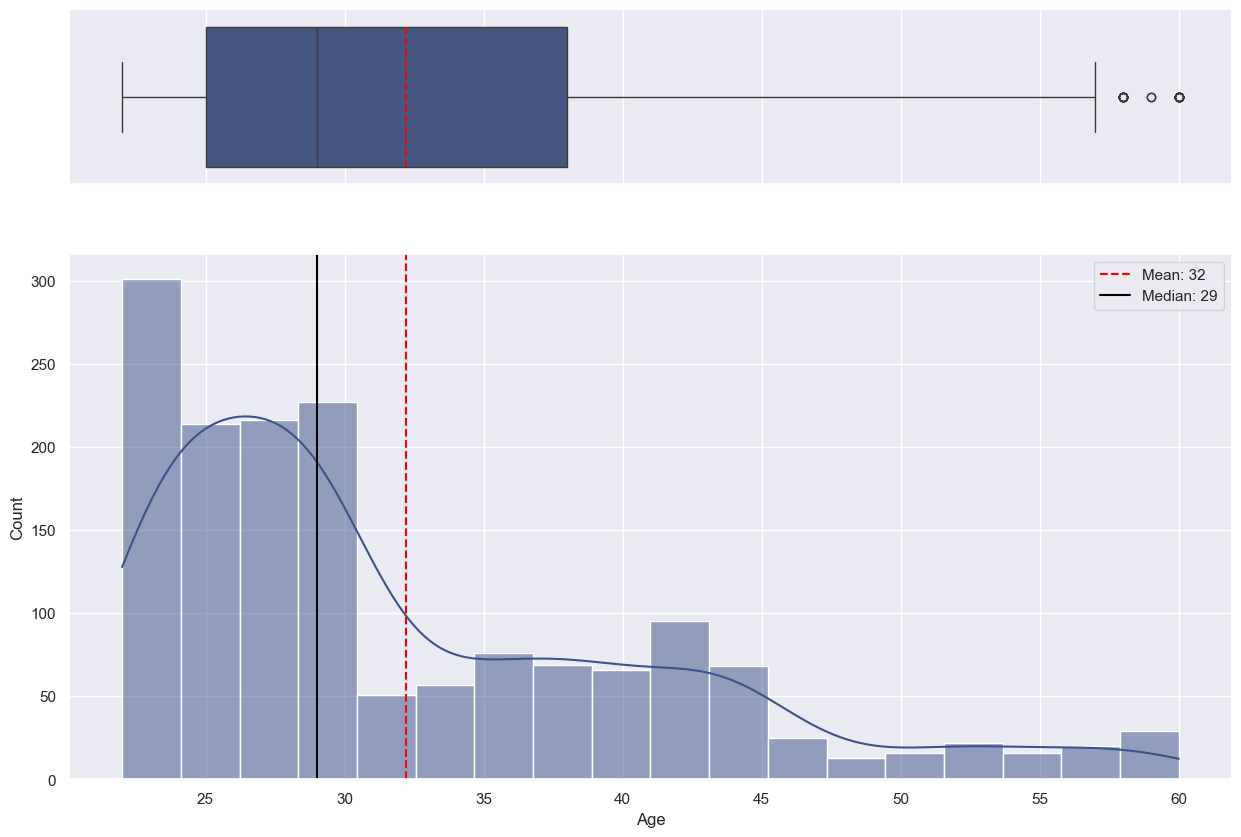

In [ ]:
histogram_boxplot(df, "Age", kde=True)



*   The distribution of age is right skewed.
*   There are some outliers.
*   There is a significant concentration of young costumers, 25% of them are between 22 and 25 years old.





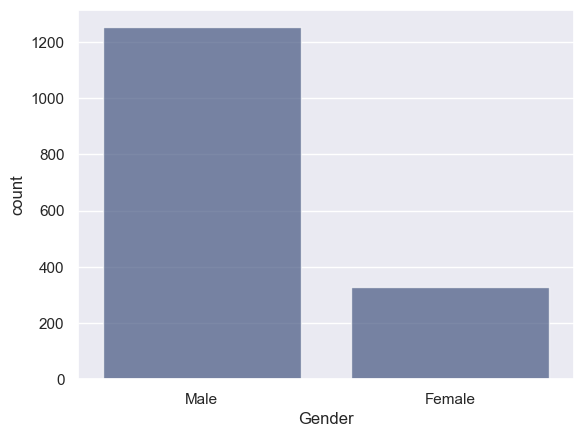

In [ ]:
sns.countplot(data=df,x='Gender', alpha=0.7)
plt.show()

* Male buyers represent over 75% of the dataset — a significant gender skew worth 
noting when building profiles.

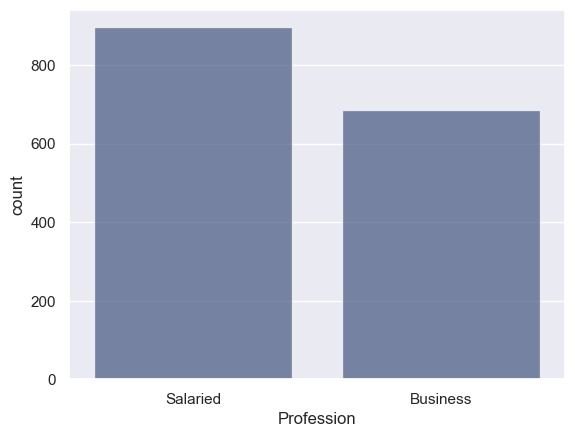

In [ ]:
sns.countplot(data=df,x='Profession', alpha=0.7)
plt.show()

*   Almost 700 buyers are business owners, while around 900 are salaried.

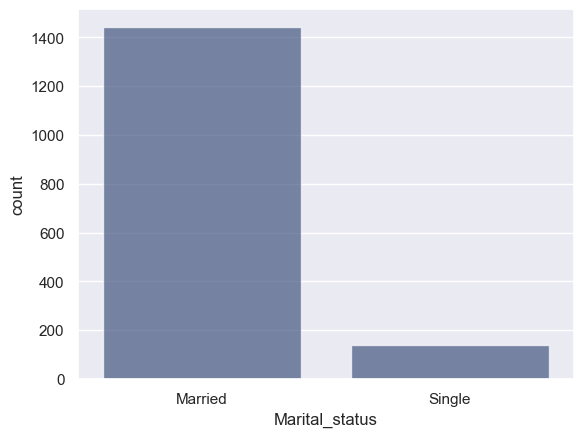

In [ ]:
sns.countplot(data=df,x='Marital_status', alpha=0.7)
plt.show()

* Married buyers dominate heavily at over 1,400 entries versus under 200 single buyers.

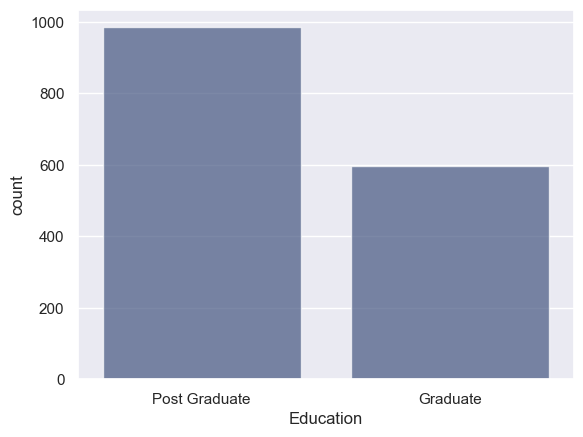

In [ ]:
sns.countplot(data=df,x='Education', alpha=0.7)
plt.show()

*   All customers in the dataset are either Graduates or Post Graduates.
*   Post Graduates are most prevalent with almost 1000 entries compared to almost 600 Graduates.




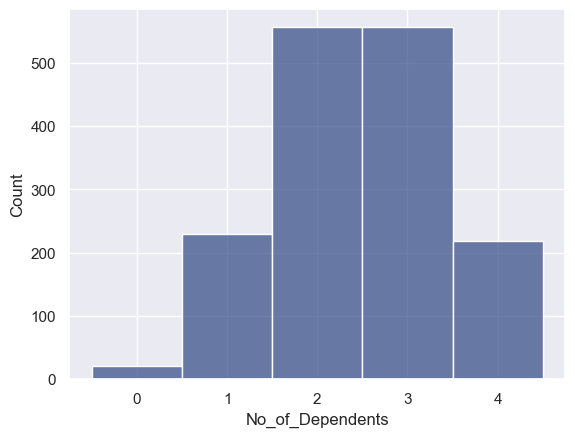

In [ ]:
sns.histplot(data=df,x='No_of_Dependents', discrete=True)
plt.show()

*   Only a very small portion of buyers have no dependents.
*   Most of them have either two or three dependents.
*   The rest have either 1 or 4 dependents.

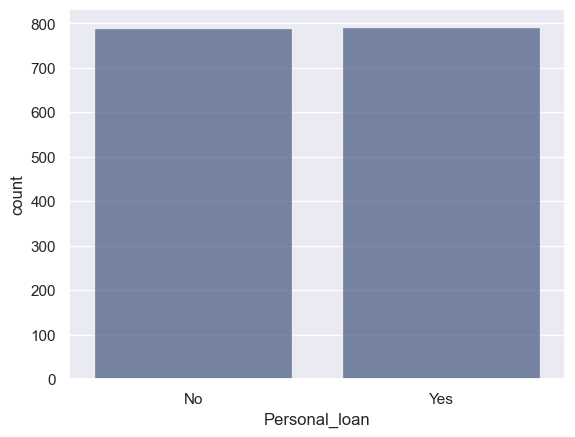

In [ ]:
sns.countplot(data=df,x='Personal_loan', alpha=0.7)
plt.show()

*   Customers are almost perfectly divided between those who have a personal loan a those who do not.

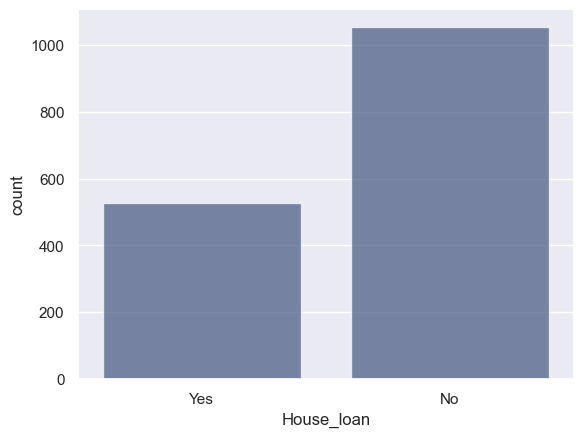

In [ ]:
sns.countplot(data=df,x='House_loan', alpha=0.7)
plt.show()

*   More than a thousand buyers do not have a house loan, while around 500 do.

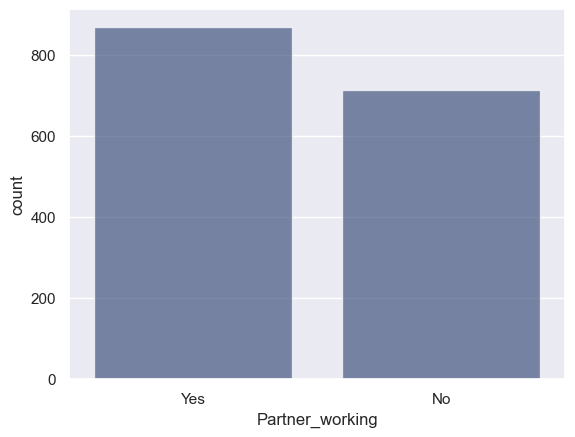

In [ ]:
sns.countplot(data=df,x='Partner_working', alpha=0.7)
plt.show()

*   Around 900 of buyers have a partner that also works, while around 700 have one that does not.

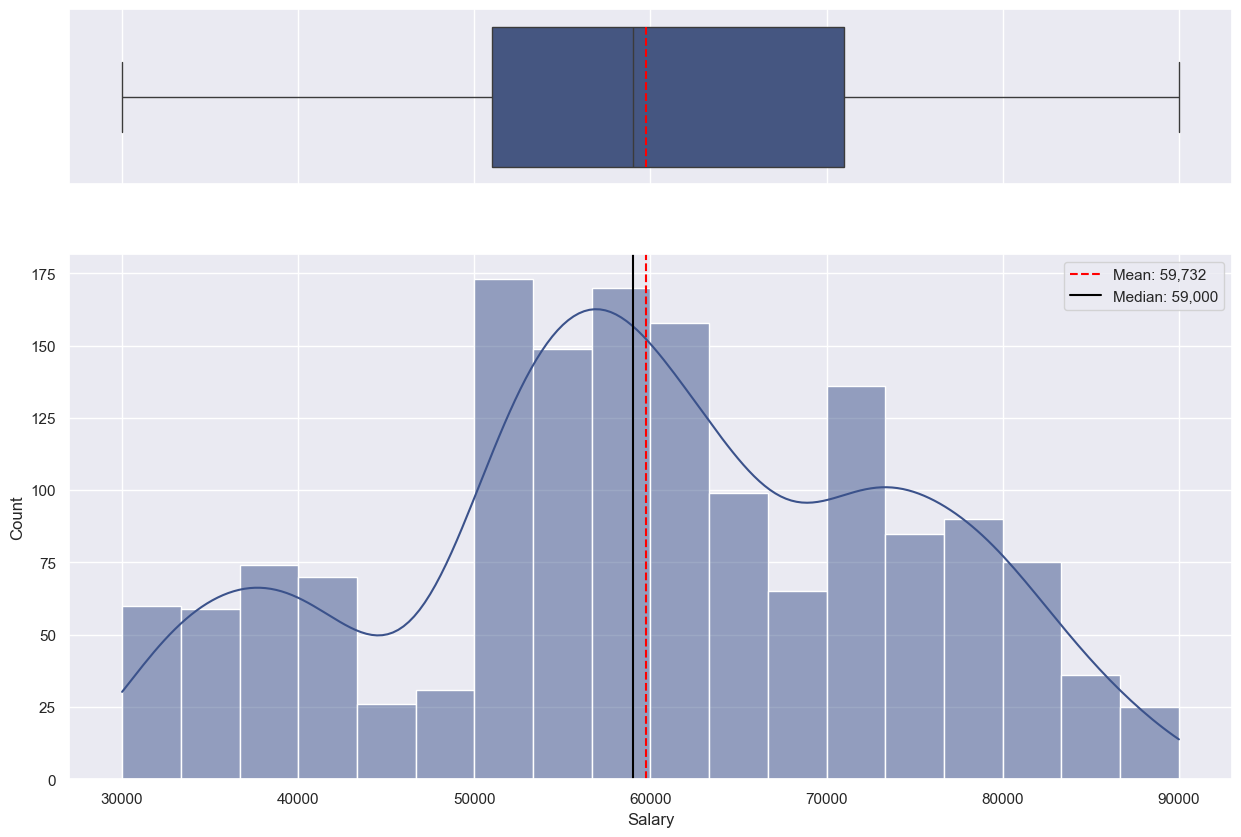

In [ ]:
histogram_boxplot(df, "Salary", kde=True)

*   Most customers have a salary that ranges between 51k and 71k.
*   The rest are on a wider spread between 30k-51k and 71k-90k.

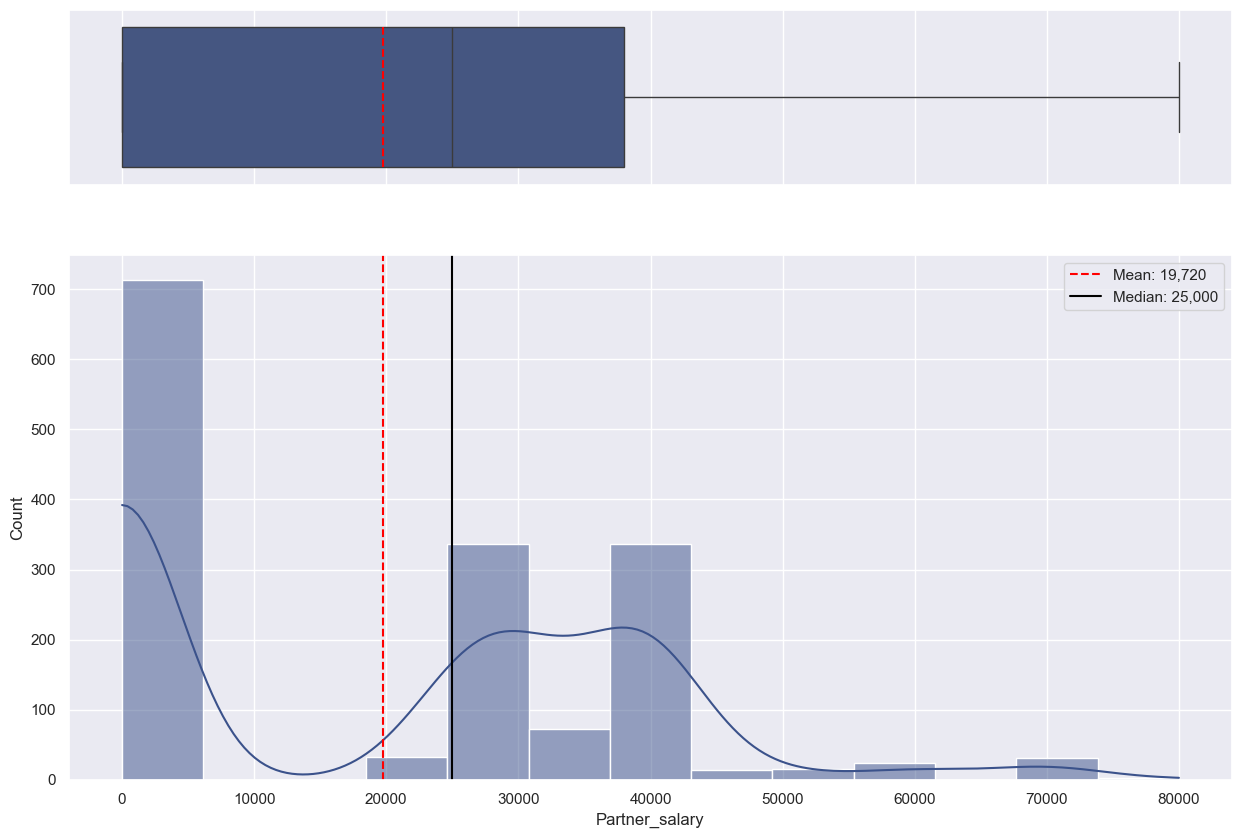

In [ ]:
histogram_boxplot(df, "Partner_salary", kde=True)

*   Most partners have no salary, which coincides with the information on the 'Partner_working' column, since all of those who are not working would represent the concentration of data at the start of this graph.
*   Out of the ones working, they mostly make between 25k and 45k, with some skew to the right after that.
* Mean and median are pulled toward zero by the large concentration of non-working partners. 
Consider interpreting this distribution in two segments: zero-salary and working partners.

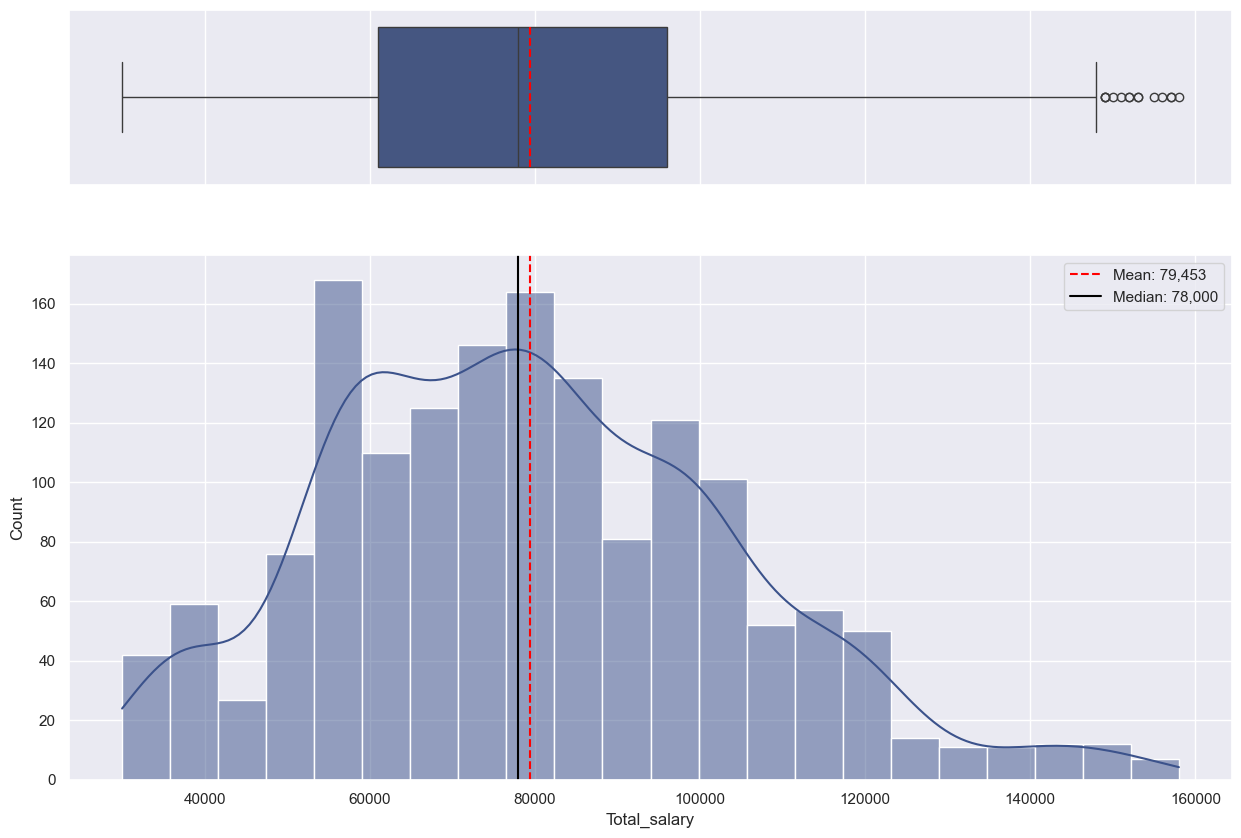

In [ ]:
histogram_boxplot(df, "Total_salary", kde=True)

* Total salary is nearly symmetrical. The right tail and outliers above 150k represent a higher 
earning segment whose purchase behavior likely differs from the median buyer.

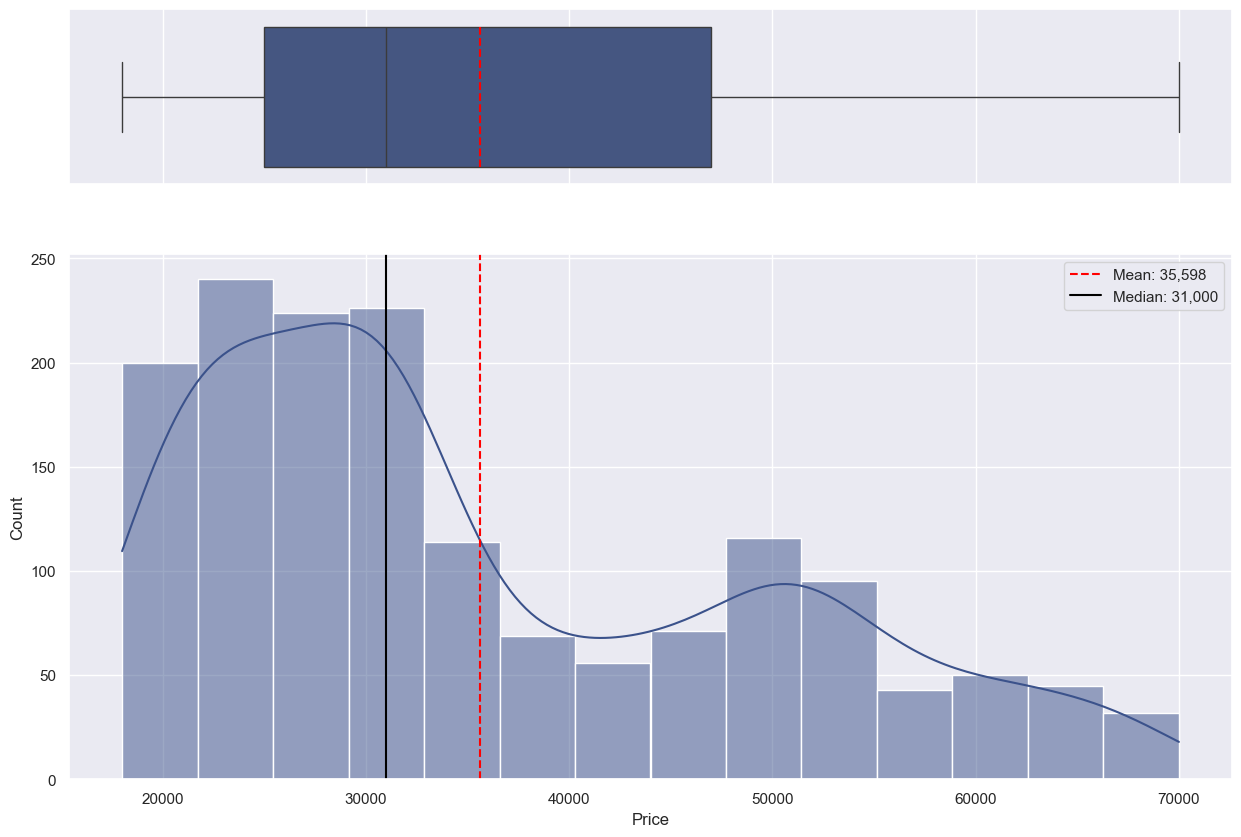

In [ ]:
histogram_boxplot(df, "Price", kde=True)

*   Price is right skewed, with a bump at around 50k.

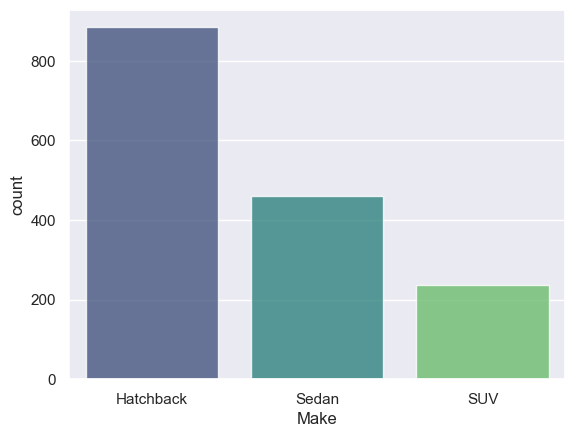

In [ ]:
sns.countplot(data=df,x='Make', alpha=0.8, palette="viridis")
plt.show()

*   Hatchback is the most prevalent make with almost 900 units sold.
*   Sedan is almost 500 and SUV a little above 200.

### Notable Findings

In [ ]:
hatchback_above_25k = len(df[(df['Make'] == 'Hatchback') & (df['Price'] > 25000)])
hatchback_above_25k

444

* 444 Hatchbacks are priced above 25,000 — suggesting a significant premium segment 
within the most popular car type.

In [ ]:
df_pricing = df[df['Price'] > df['Salary']]
print(len(df_pricing), 'buyers purchased cars priced above their annual salary.')
print(len(df_pricing[df['Personal_loan'] == 'Yes']), 'of those took a personal loan.')

96 buyers purchased cars priced above their annual salary.
44 of those took a personal loan.


* 96 buyers purchased cars exceeding their annual salary — 44 of whom financed via 
personal loan. This suggests aspirational purchasing behavior worth profiling separately.

### Multivariate Analysis

The following analysis introduces `Make` as the primary differentiator, 
exploring how demographic and financial variables relate to car segment preference.

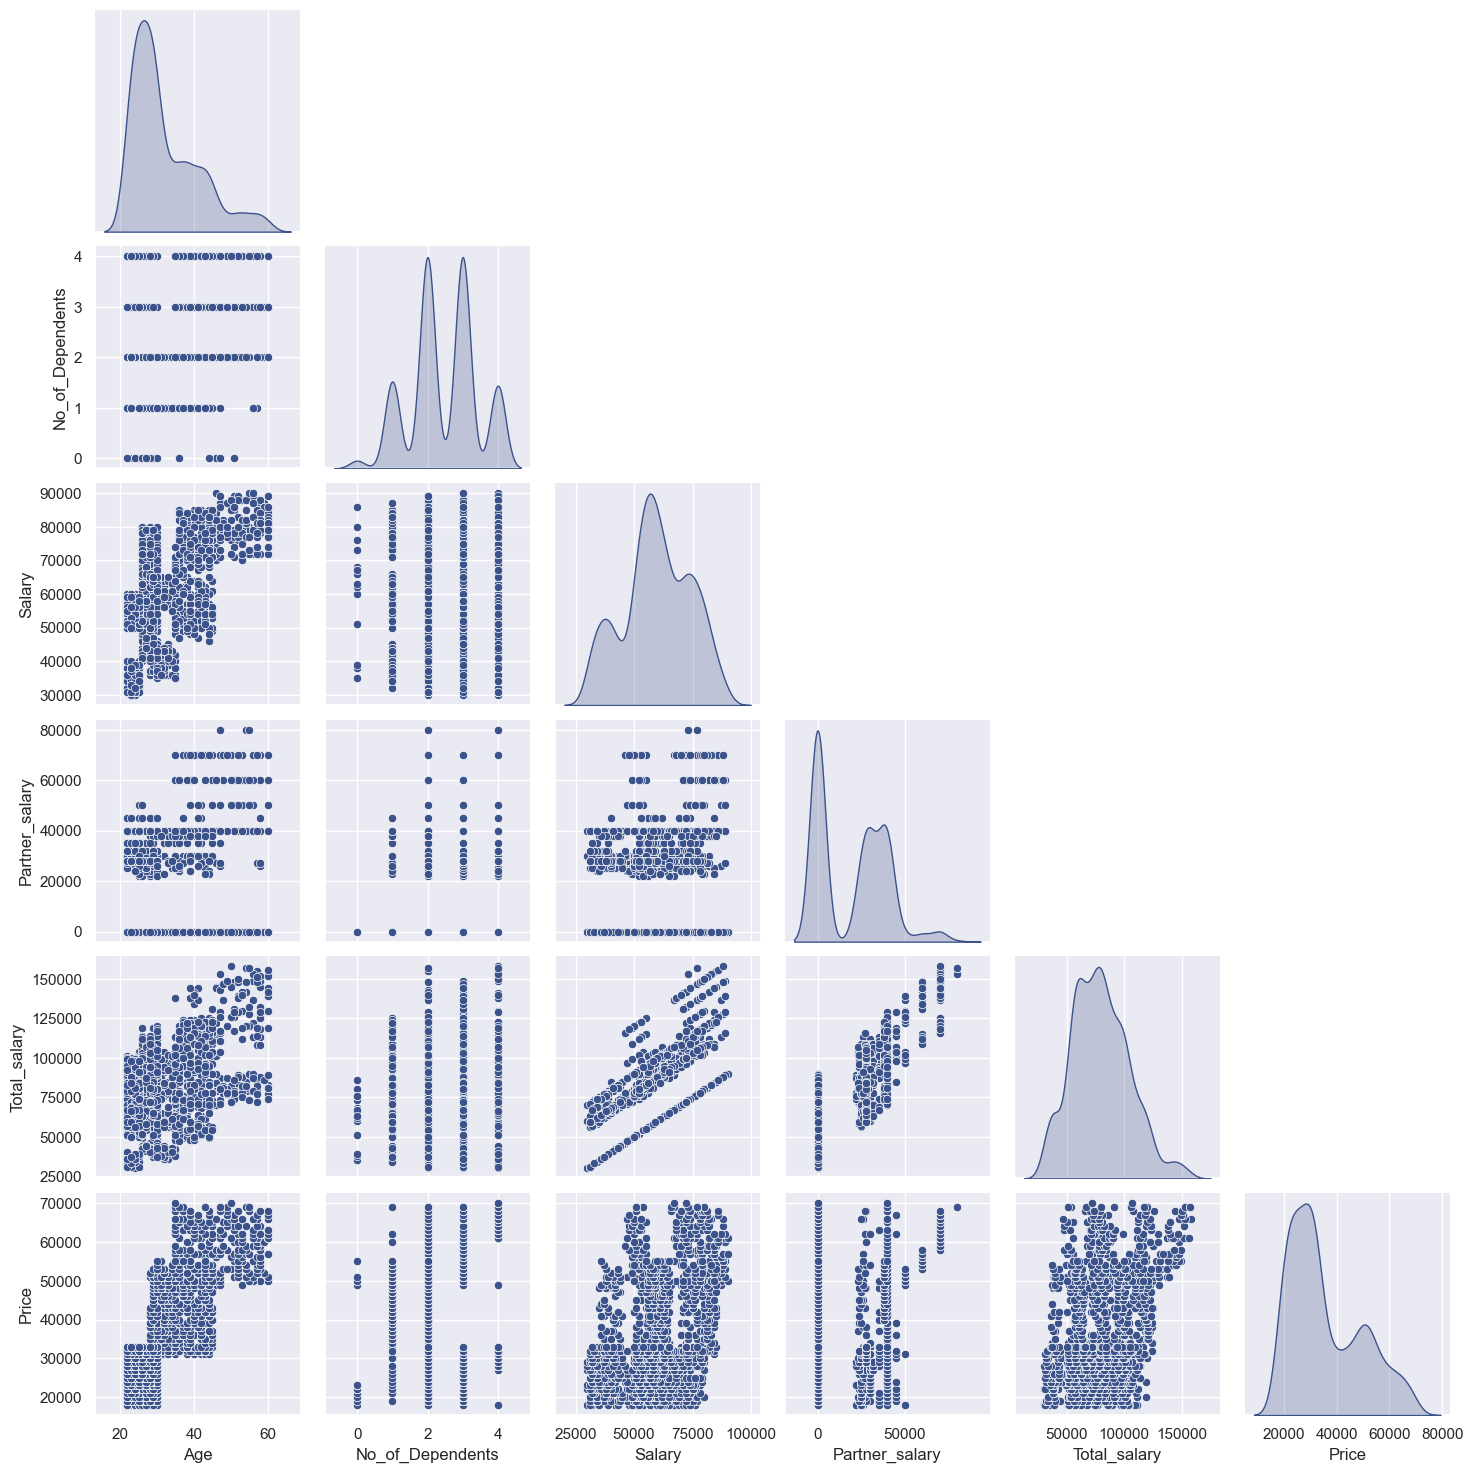

In [ ]:
sns.pairplot(data=df, diag_kind = "kde", corner='True')
plt.show()

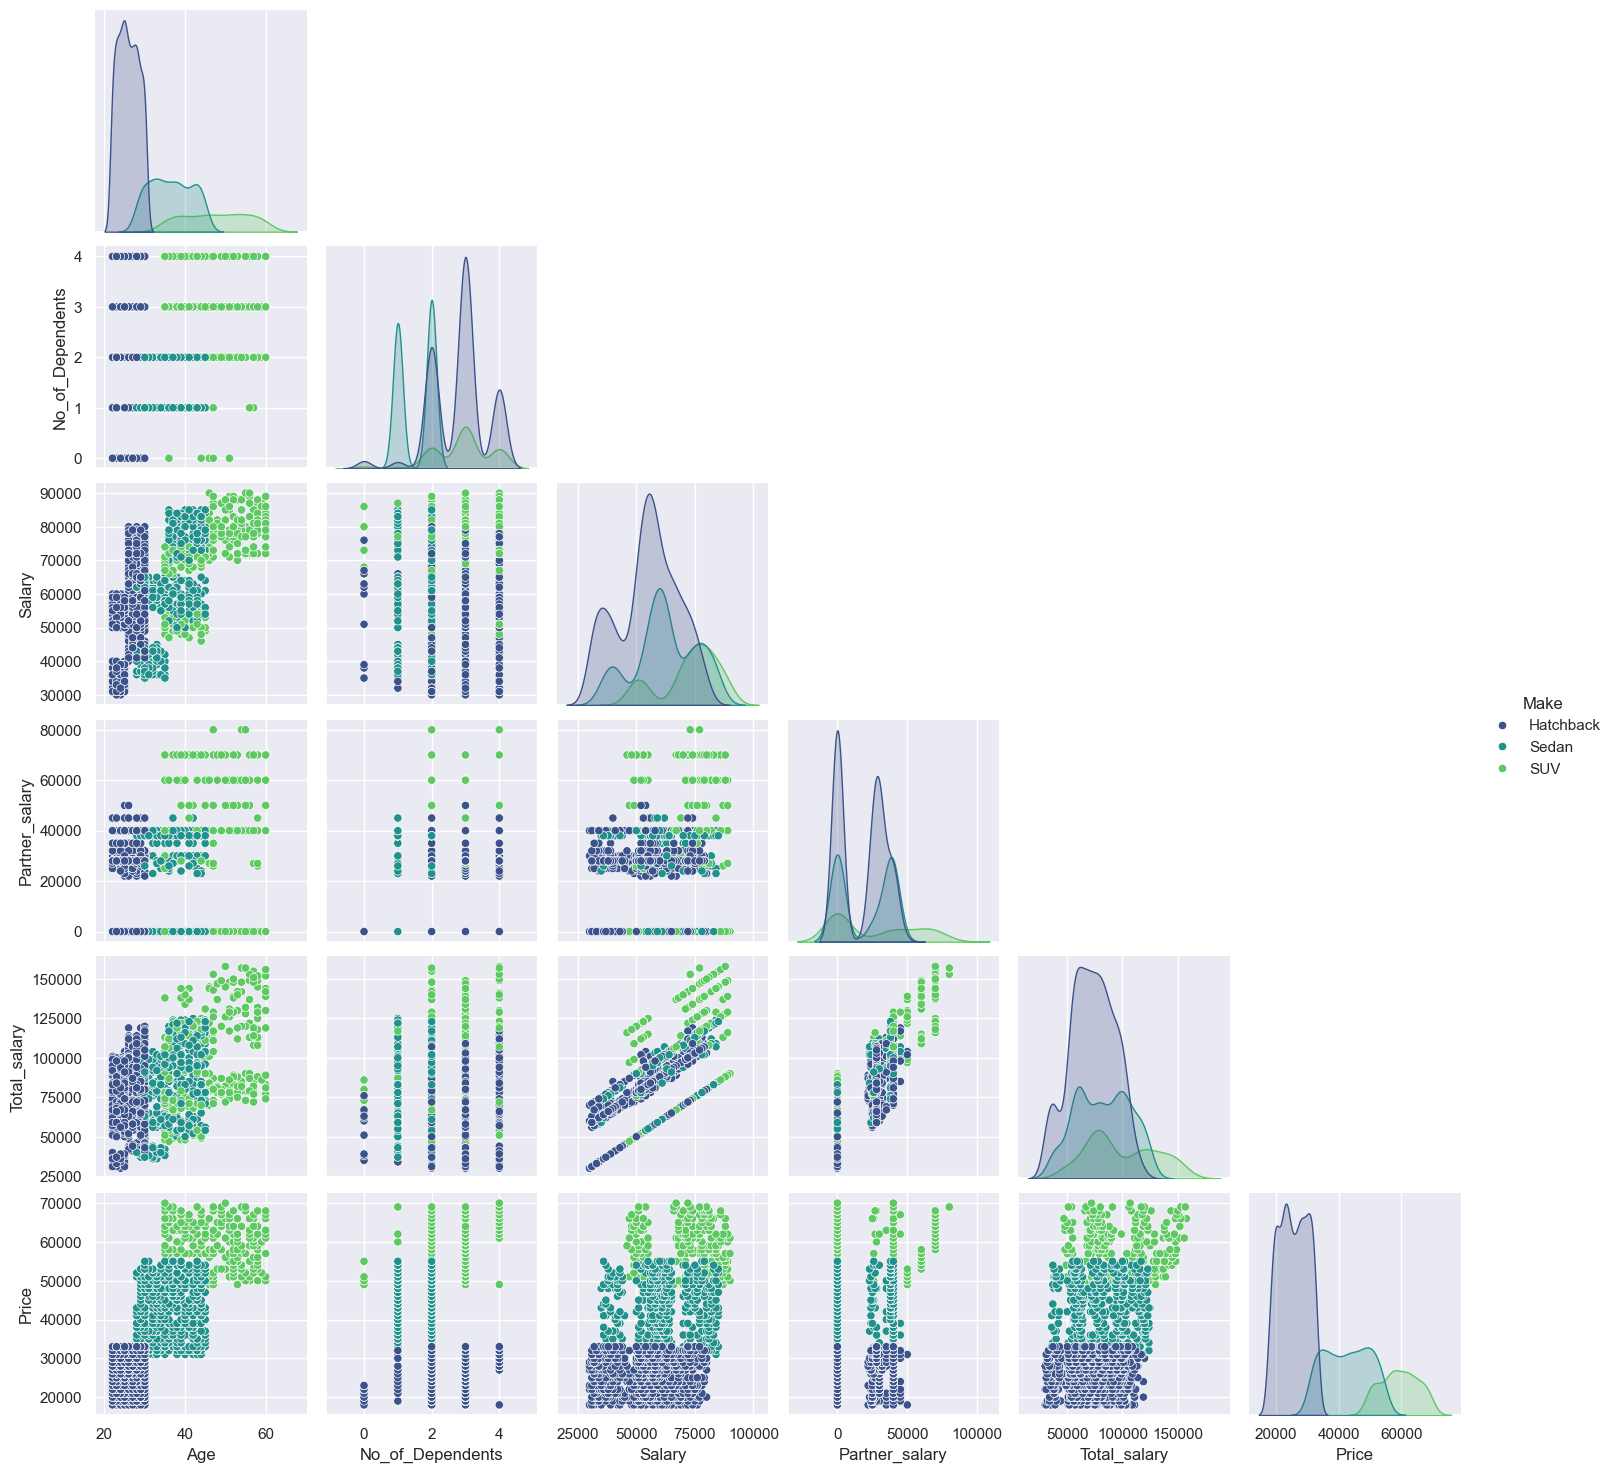

In [ ]:
sns.pairplot(data=df, hue = "Make", diag_kind = "kde", corner='True')
plt.show()

* Make is highly correlated to both price and age — younger buyers choose 
lower-priced hatchbacks, middle-aged buyers choose mid-range sedans, and 
older buyers select premium SUVs. Salary plays a secondary role — 
SUVs are simply not purchased by low-earning clients.

* The Age → Make → Price relationship forms the foundation of the buyer 
profiles developed in the next section.

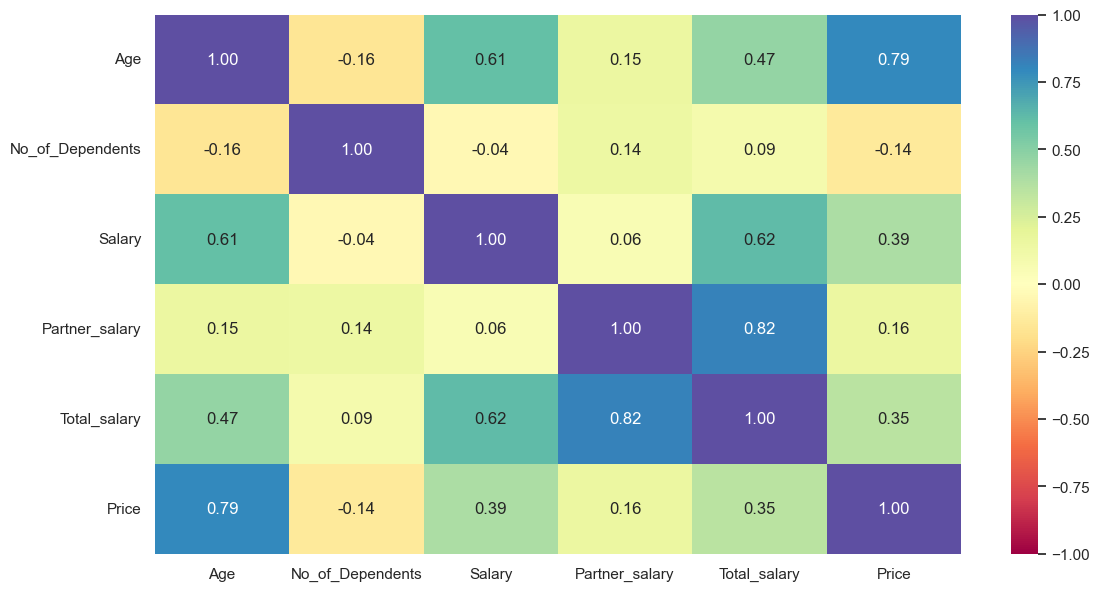

In [ ]:
plt.figure(figsize=(13, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

In [ ]:
len(df[df["Partner_salary"]==0])

713

*   Partner salary and total salary are mostly correlated because 713 entries have partner salary as 0. So naturally as Partner salary increases, the sum of it with the customer's salary does so as well.
*   Also it seems that the older a customer gets, the more they spend on their car.
*   As well the older the customer is, the higher their salary tends to be.
*   There is some correlation between Salary and Price, which is logical.
*   Most other variables do not present significant correlation.

Make - Price

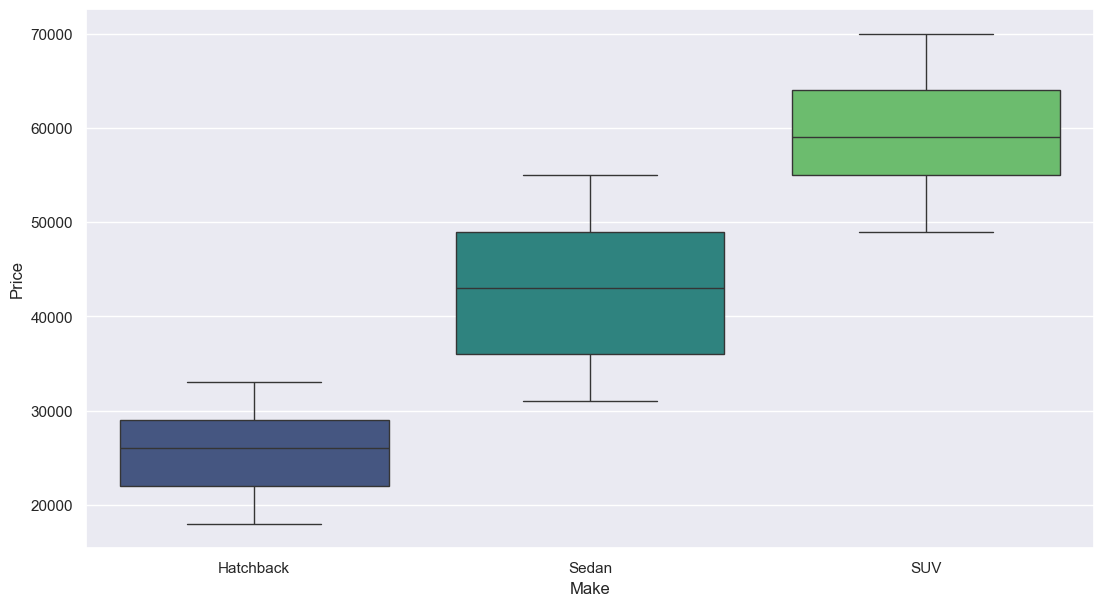

In [ ]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x="Make", y="Price", palette="viridis")
plt.show()

*   Here we confirm something simple, the general order for pricing is hatchback at the lowest prices, sedan at the mid range and SUV's the highest priced.

Make - Age

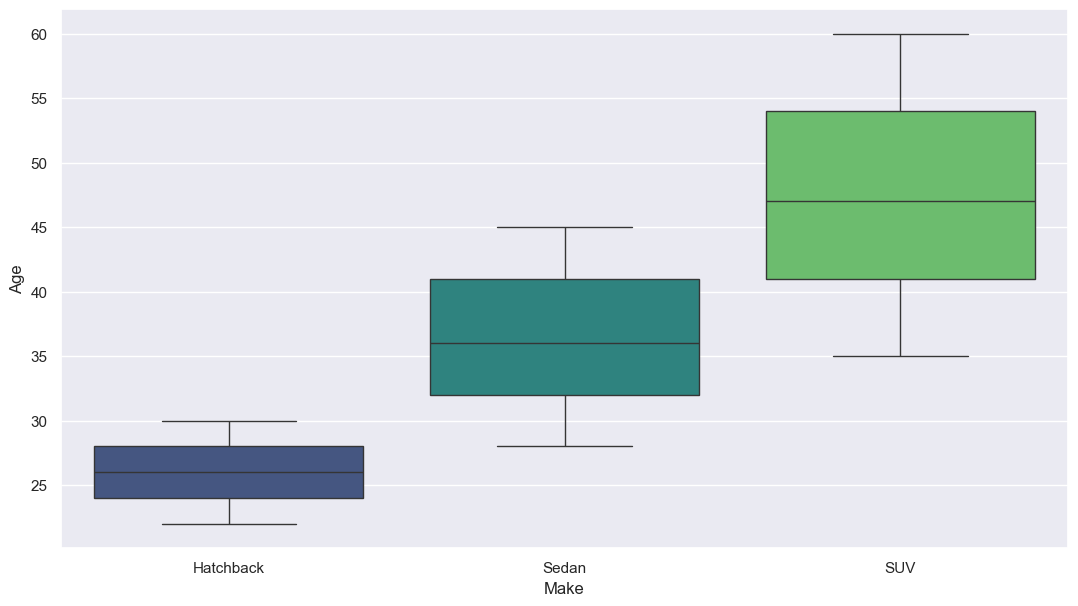

In [ ]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x="Make", y="Age", palette="viridis")
plt.show()

*   We can clearly confirm here how age is highly correlated to make.

Make - Salary

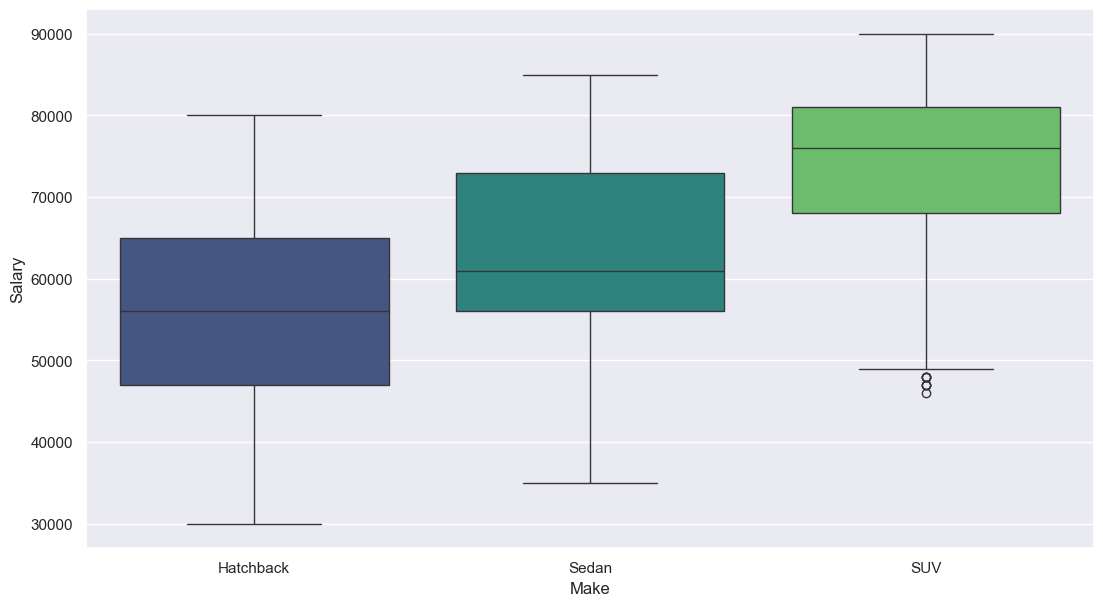

In [ ]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x="Make", y="Salary", palette="viridis")
plt.show()

*   In this boxplot we observe a slight correlation between make and salary, but the distribution of all three makes is more widely spread. Age remains quite more relevant than salary when it comes to choosing a certain type of car make.

Make - Education

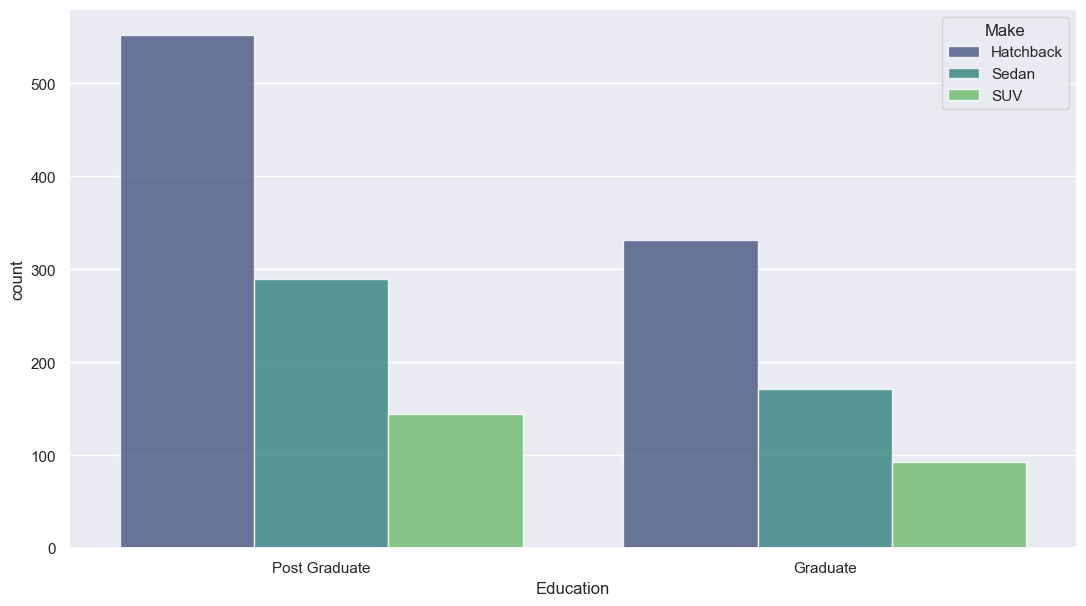

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Education", hue="Make", alpha=0.8)
plt.show()

* Make distribution is proportionally consistent across education levels, 
suggesting education has low predictive value for car segment preference.
* Most clients observed in the dataset are Post-Graduates.

Make - Profession

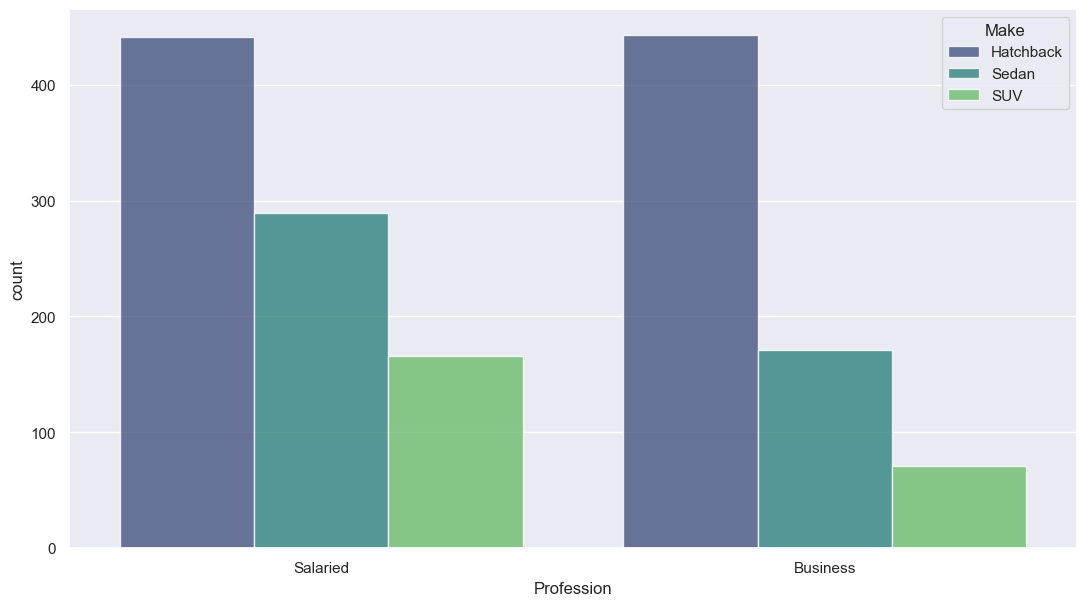

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Profession", hue="Make", alpha=0.8)
plt.show()

* Business owners show a slightly higher proportion of hatchback preference 
compared to salaried buyers.

Make - Number of dependents

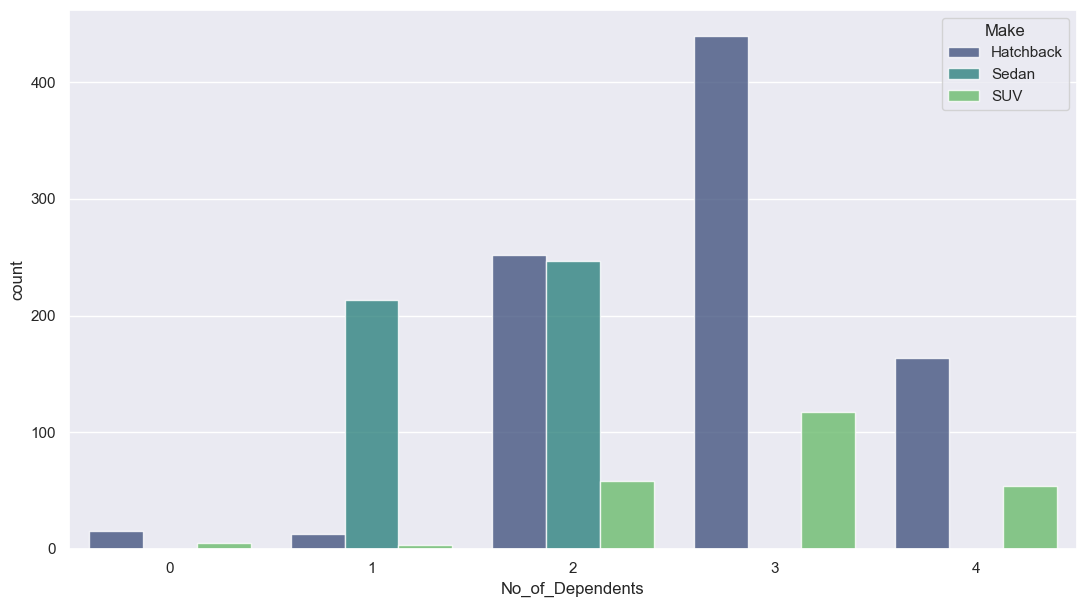

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="No_of_Dependents", hue="Make", alpha=0.8)
plt.show()

*   In this dataset, clients with zero dependents buy either hatchbacks or SUV's, but not sedans. We can also conclude that there are very little clients with no dependents.
*   Clients with one dependent have a strong preference for sedans.
*   Clients with two dependents buy mostly either hatchbacks or sedans, some of them buy SUV's.
*   Clients with three dependents buy mostly hatchbacks, some of them buy SUV's and none buy sedans.
*   Finally, clients with four dependents also mostly buy hatchbacks, some of them buy SUV's and none buy sedans.

Make - Personal loan

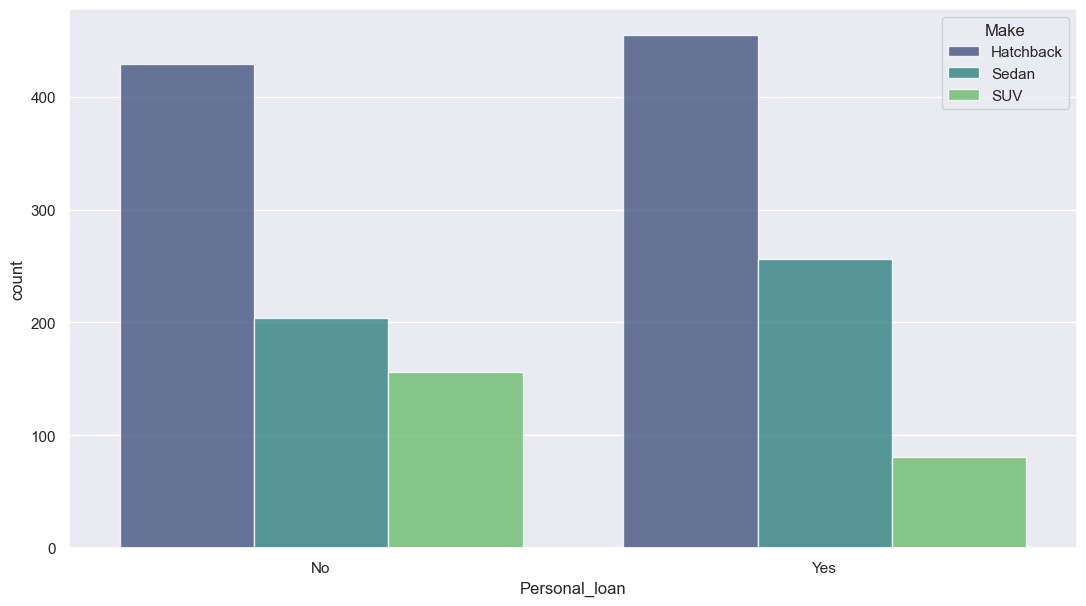

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Personal_loan", hue="Make", alpha=0.8)
plt.show()

* Only a modest relationship between personal loan and car segment preference; clients with personal loans buy less SUV's proportionally.

Make - House loan

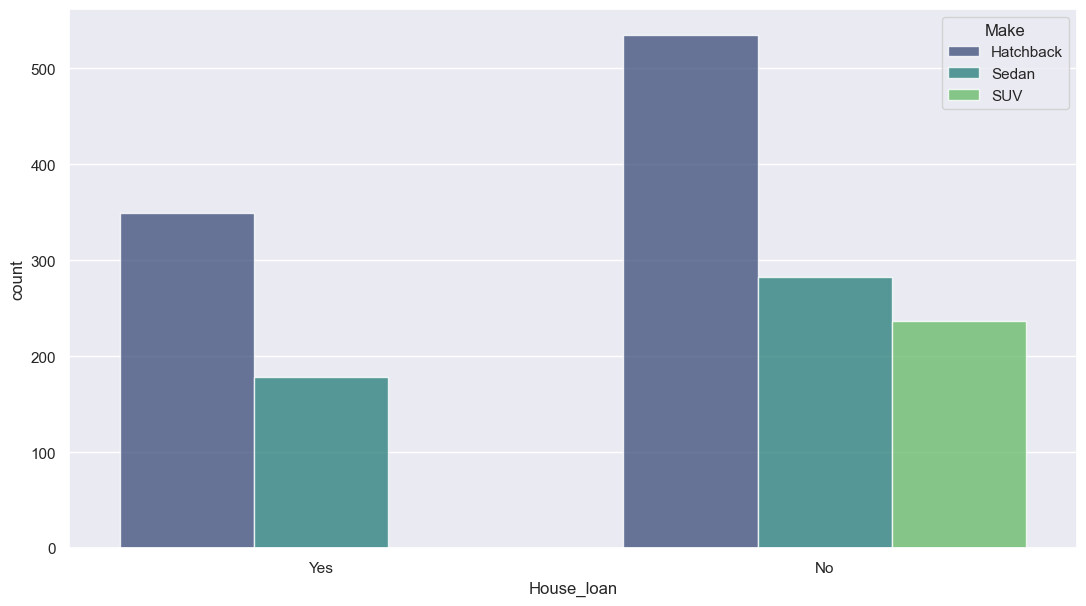

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="House_loan", hue="Make", alpha=0.8)
plt.show()

*   Clients who have taken a  house loan do not buy SUV's, and also in general are less common car buyers.

Make - Gender

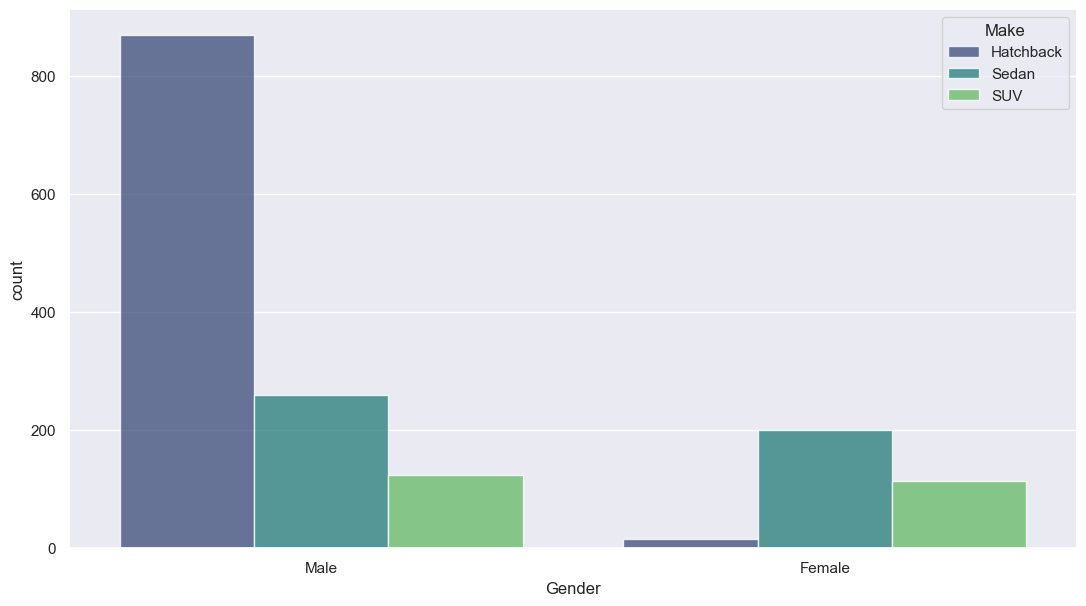

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Gender", hue="Make", alpha=0.8)
plt.show()

* Hatchbacks skew male. Sedans and SUVs show near-equal gender distribution — 
suggesting gender is more relevant for entry-level segment targeting.

Make - Marital status

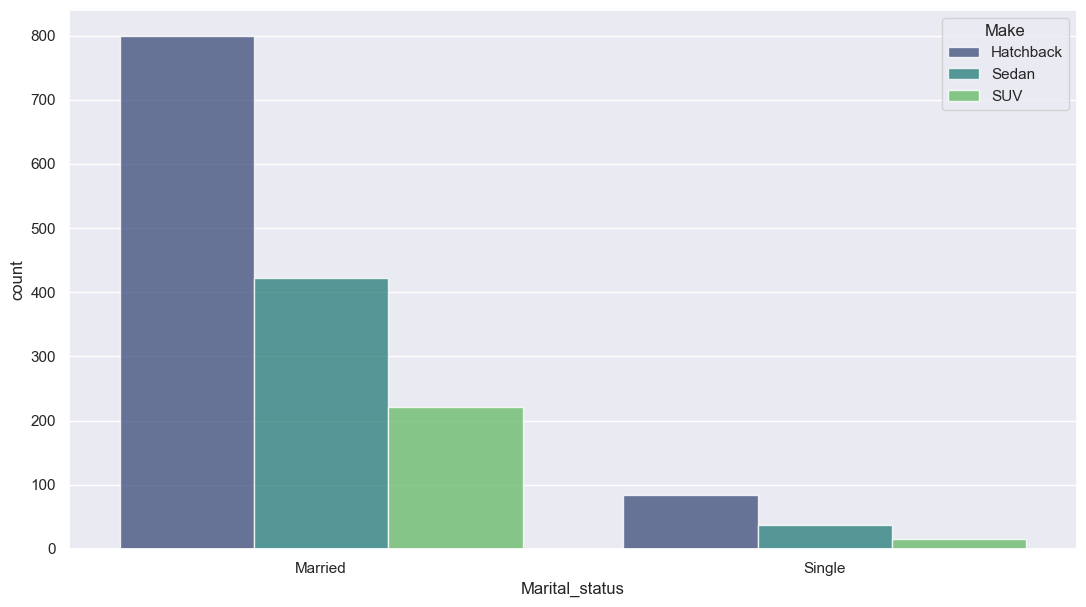

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Marital_status", hue="Make", alpha=0.8)
plt.show()

* Marital status shows no meaningful differentiation across segments — 
married buyers dominate all three makes proportionally.

Make - Partner working

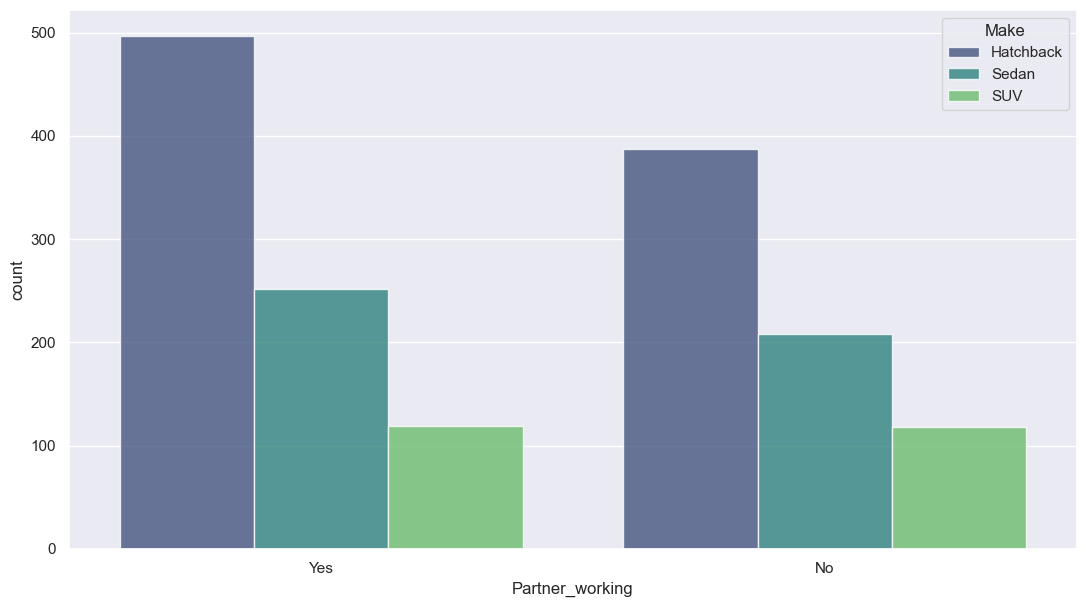

In [ ]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Partner_working", hue="Make", alpha=0.8)
plt.show()

* Hatchback buyers specially, and sedan buyers are more likely to have a working partner. 
* SUV buyers show no clear pattern. 



---



## Buyer Profiles by Make

### **HATCHBACK BUYER PROFILE**

In [ ]:
df[df["Make"]=="Hatchback"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,884.000000,884,884,884,884,884.000000,884,884,884,884.000000,884.000000,884.000000,884.000000,884
unique,NaN,2,2,2,2,NaN,2,2,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Business,Married,Post Graduate,NaN,Yes,No,Yes,NaN,NaN,NaN,NaN,Hatchback
freq,NaN,869,443,800,552,NaN,455,535,497,NaN,NaN,NaN,NaN,884
mean,25.874434,NaN,NaN,NaN,NaN,2.820136,NaN,NaN,NaN,54969.457014,17707.013575,72676.470588,25561.085973,NaN
std,2.520373,NaN,NaN,NaN,NaN,0.806543,NaN,NaN,NaN,12798.737168,16250.833815,20078.257725,4425.257139,NaN
min,22.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,30000.000000,0.000000,30000.000000,18000.000000,NaN
25%,24.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,47000.000000,0.000000,58000.000000,22000.000000,NaN
50%,26.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,56000.000000,25000.000000,73000.000000,26000.000000,NaN
75%,28.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,65000.000000,30000.000000,88000.000000,29000.000000,NaN


* The most typical Hatchback buyer is a 26 year old, married, business owner male. With 2 or 3 kids, a post graduate degree, a personal loan but not a house loan. He has an average salary of 55k, their partner usually works and the sum of their salary on average is around 72.6k. The hatchback he usually buys costs 25.5k.**

### **SEDAN BUYER PROFILE**

In [ ]:
df[df["Make"]=="Sedan"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,460.000000,460,460,460,460,460.000000,460,460,460,460.000000,460.000000,460.000000,460.000000,460
unique,NaN,2,2,2,2,NaN,2,2,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Salaried,Married,Post Graduate,NaN,Yes,No,Yes,NaN,NaN,NaN,NaN,Sedan
freq,NaN,259,289,422,289,NaN,256,282,252,NaN,NaN,NaN,NaN,460
mean,36.458696,NaN,NaN,NaN,NaN,1.536957,NaN,NaN,NaN,62213.043478,20028.260870,82241.304348,42671.739130,NaN
std,5.093080,NaN,NaN,NaN,NaN,0.499175,NaN,NaN,NaN,13195.787416,18584.355909,23929.007894,7096.507565,NaN
min,28.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,35000.000000,0.000000,36000.000000,31000.000000,NaN
25%,32.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,56000.000000,0.000000,61000.000000,36000.000000,NaN
50%,36.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,61000.000000,27000.000000,82000.000000,43000.000000,NaN
75%,41.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,73000.000000,38000.000000,101250.000000,49000.000000,NaN


* The most typical Sedan buyer is a 36 year old, married, salaried male (although many females are also buyers). With 1 or 2 kids, a post graduate degree, with a personal loan and no house loan. An average salary of 62k, their partner usually works and the sum of their salary on average is around 82k. The sedan he usually buys is around 42.6k.**

### **SUV BUYER PROFILE**

In [ ]:
df[df["Make"]=="SUV"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,237.000000,237,237,237,237,237.000000,237,237,237,237.000000,237.000000,237.000000,237.000000,237
unique,NaN,2,2,2,2,NaN,2,1,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Salaried,Married,Post Graduate,NaN,No,No,Yes,NaN,NaN,NaN,NaN,SUV
freq,NaN,124,166,221,144,NaN,156,237,119,NaN,NaN,NaN,NaN,237
mean,47.603376,NaN,NaN,NaN,NaN,2.894515,NaN,NaN,NaN,72683.544304,26632.911392,99316.455696,59303.797468,NaN
std,7.733023,NaN,NaN,NaN,NaN,0.839600,NaN,NaN,NaN,12165.048890,28590.109059,30509.741833,5829.544340,NaN
min,35.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,46000.000000,0.000000,47000.000000,49000.000000,NaN
25%,41.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,68000.000000,0.000000,76000.000000,55000.000000,NaN
50%,47.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,76000.000000,25000.000000,89000.000000,59000.000000,NaN
75%,54.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,81000.000000,50000.000000,125000.000000,64000.000000,NaN


* The most typical SUV buyer can be either male or female. Is 47 years old, married and salaried. 2, 3 or 4 kids, post graduate degree, with neither personal loan nor house loan. An average salary of 72k, their partner could work or not and usually contributes to the sum of their salaries for a total of 99k. He or she usually buys an SUV priced around 59.3k**

### Supporting Analysis

In [ ]:
df_dependents = df[df["No_of_Dependents"]<= 3]
df_profession = df_dependents.groupby(['Profession'])['Price'].mean().sort_values(ascending = False).reset_index()
df_profession

,Profession,Price
0,Salaried,37036.175711
1,Business,32830.220713


* Among buyers with 3 or fewer dependents, salaried professionals spend 
more on average (~37k) than business owners (~32.8k) — a counterintuitive 
finding given that business owners might be expected to have higher purchasing power.

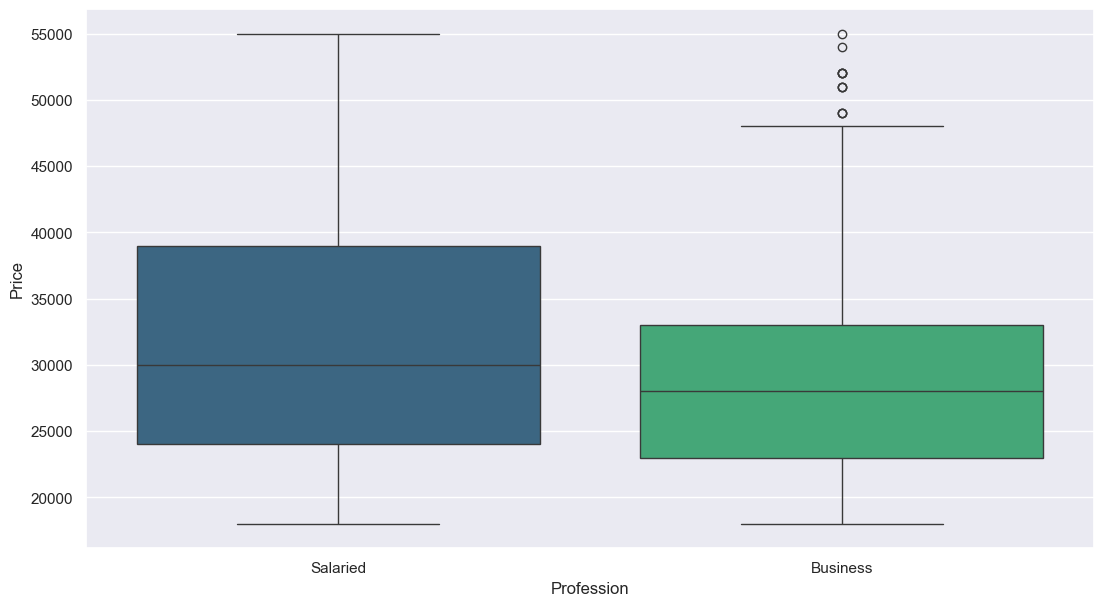

In [ ]:
df_loan = df[(df['Personal_loan'] == 'Yes') & (df['House_loan'] == 'Yes')]

plt.figure(figsize=(13,7))
sns.boxplot(data=df_loan, x='Profession', y='Price', palette='viridis')
plt.show()

* Among buyers carrying both personal and house loans, salaried clients 
spend more on cars than business owners — consistent with the previous finding 
and suggesting business owners may be more conservative with discretionary spending 
when leveraged.

## Conclusion and Recommendations

#### **Question 12:** Write the conclusions and business recommendations derived from the analysis. (6 marks)

A variety of profiles could be made taking different variables at the source of the analysis, yet profiling the buyers around the three company products present in the data gives a clear view of the market's characteristics; specially when accompanied by the previous analysis of single and paired variables.


# Detailed buyer profiles by make






> Here a more outlined version of a buyer profile for each car make is given.



### Task:
To compare and contrast the three buyer profiles (Hatchback, Sedan, SUV) to highlight their unique traits, overlapping characteristics, and significant differences. Identifying patterns and insights relevant to Austo's market entry.








**Hatchback Buyer Profile**
*   **Age:** Youngest (average 26 years old), predominantly 22-30.
*   **Gender:** Primarily Male (869 Male vs. 15 Female).
*   **Profession:** Balanced (443 business owners vs. 441 salaried)
*   **Marital Status:** Mostly Married.
*   **Education:** Post Graduate (around 62%)
*   **No. of Dependents:** Typically 2 or 3 dependents, with some 0 and 4.
*   **Personal Loan:** Slightly more likely to have a personal loan.
*   **House Loan:** More likely NOT to have a house loan.
*   **Partner Working:** Slightly more likely to have a working partner.
*   **Salary:** Lowest average individual salary (approx. 55k).
*   **Total Salary:** Lowest average household income (approx. 72.6k).
*   **Price:** Lowest average car price (approx. 25.5k).






**Sedan Buyer Profile**
*   **Age:** Middle-aged (average 36 years old), predominantly 28-45.
*   **Gender:** Balanced (259 Male vs. 201 Female).
*   **Profession:** Predominantly Salaried (around 63%).
*   **Marital Status:** Mostly Married.
*   **Education:** Post Graduate (around 63%).
*   **No. of Dependents:** Typically 1 or 2 dependents.
*   **Personal Loan:** Slightly more likely to have a personal loan.
*   **House Loan:** More likely NOT to have a house loan.
*   **Partner Working:** Slightly more likely to have a working partner.
*   **Salary:** Mid-range average individual salary (approx. 62k).
*   **Total Salary:** Mid-range average household income (approx. 82k).
*   **Price:** Mid-range average car price (approx. 42.6k).






**SUV Buyer Profile**
*   **Age:** Oldest (average 47 years old), predominantly 35-60.
*   **Gender:** Balanced (124 Male vs. 113 Female).
*   **Profession:** Predominantly Salaried (around 70%).
*   **Marital Status:** Mostly Married.
*   **Education:** Post Graduate (around 61%).
*   **No. of Dependents:** Typically 2, 3 or 4 dependents.
*   **Personal Loan:** More likely NOT to have a personal loan.
*   **House Loan:** Does NOT have a house loan.
*   **Partner Working:** Balanced likelihood of having a working partner or not.
*   **Salary:** Highest average individual salary (approx. 72k).
*   **Total Salary:** Highest average household income (approx. 99k).
*   **Price:** Highest average car price (approx. 59.3k).






### Common Traits and Overlapping Characteristics
*   **Marital Status:** All three profiles are predominantly **Married**.
*   **Education:** All three profiles have a majority of **Post Graduate** individuals.
*   **House Loan:** The majority of buyers across all categories do not have a house loan, with SUV buyers having no house loans.
*   **Professional Segmentation:** Both Salaried and Business professionals are present in all categories, though their proportions vary.

### Significant Differences and Unique Traits
*   **Age and Price Correlation:** A strong positive correlation exists between buyer age and car price. Hatchback buyers are the youngest and buy the cheapest cars, Sedan buyers are middle-aged with mid-priced cars, and SUV buyers are the oldest with the most expensive cars.
*   **Gender Distribution:** Hatchback buyers are overwhelmingly male, while Sedan and SUV buyers show a more balanced gender distribution.
*   **Profession:** Hatchback buyers lean very slightly towards Business professionals, whereas Sedan and SUV buyers are predominantly Salaried.
*   **Number of Dependents:** Hatchback and SUV buyers tend to have more dependents (2-4), while Sedan buyers mostly have fewer (1-2).
*   **Loan Status:** Personal loan distribution is fairly even for Hatchback and Sedan, but SUV buyers are less likely to have personal loans. SUV buyers notably have *no* house loans.
*   **Income Levels:** There's a clear progression in individual and total household income, directly corresponding to the car segment (Hatchback < Sedan < SUV).

### Key Patterns and Insights for Austo's Market Entry
1.  **Age-Based Market Segmentation:** Austo should target younger demographics (22-30) with cost-effective Hatchbacks, middle-aged customers (28-45) with Sedans, and older, more affluent customers (35-60) with SUVs. This implies marketing strategies tailored to each age group's lifestyle and financial capacity.
2.  **Financial Capacity and Car Choice:** There's a direct relationship between salary (individual and total household) and the price/type of car purchased. Austo can leverage this by positioning different car models at various price points to cater to different income brackets.
3.  **Gender-Specific Marketing for Hatchbacks:** Given the strong male dominance in the Hatchback segment, Austo's marketing for Hatchbacks could be more male-centric, while Sedan and SUV campaigns should appeal to a broader gender audience. Having said this, the imbalance could also suggest an unexplored market.
4.  **Family-Oriented Messaging:** The high number of dependents for Hatchback and SUV buyers suggests that family-centric features (space, safety, utility) could be strong selling points for these segments. Sedan buyers, with fewer dependents, might be more interested in performance or comfort.
5.  **Loan Status and Purchasing Power:** SUV buyers, who typically have higher incomes and no house loans, appear to have greater financial flexibility, indicating they are less price-sensitive and potentially open to premium features or higher-end models. Marketing for SUVs could focus on luxury, advanced features, and status rather than just affordability.

### Business Recommendations for Austo

Based on the analysis and synthesized buyer profiles, here are actionable business recommendations for Austo:

#### 1. Hatchback Recommendations

*   **Marketing Strategies:**
    *   **Target Audience:** Young, married male business owners (around 26 years old) with 2-3 dependents and postgraduate degrees, who often have personal loans.
    *   **Messaging:** Emphasize affordability, practicality for small families (e.g., adequate space for 2-3 kids), fuel efficiency, and perhaps stylish designs that appeal to a younger, budget-conscious business professional. Highlight features that support daily commuting and light family use.
    *   **Channels:** Digital marketing campaigns on platforms popular with young professionals and small business owners, social media ads focusing on lifestyle and cost-effectiveness, partnerships with financial institutions for personal loan tie-ups.

*   **Product Positioning:**
    *   **Value Proposition:** Position Hatchbacks as the "Smart Start" car – an economical, versatile, and modern choice for young families and budding entrepreneurs. Focus on low running costs and entry-level luxury/technology.
    *   **Price Point:** Maintain the competitive price range of around $25,500, possibly offering attractive financing options given the propensity for personal loans.

*   **Potential Areas for Growth or Focus:**
    *   **Features:** Integrate modern infotainment systems, advanced safety features suitable for young families (e.g., child seat anchors, basic driver-assist features), and perhaps customizable interior options to appeal to individualistic business owners.
    *   **After-sales:** Offer attractive service packages and extended warranties to further reduce perceived cost of ownership.
    *   **Demographic Expansion:** Explore slight modifications or marketing angles to appeal to single young professionals or smaller families with fewer dependents if the market shows potential there.

#### 2. Sedan Recommendations

*   **Marketing Strategies:**
    *   **Target Audience:** Middle-aged (around 36 years old), married salaried males (and a good number of females) with 1-2 dependents and postgraduate degrees. They also tend to have personal loans.
    *   **Messaging:** Focus on comfort, reliability, executive styling, and a balance between family utility and professional image. Highlight features that enhance daily commutes and occasional family trips. Emphasize a step up in status from a hatchback.
    *   **Channels:** Targeted ads in professional journals/websites, family-oriented lifestyle magazines, online platforms catering to mid-career professionals, and dealership promotions that emphasize upgrade opportunities.

*   **Product Positioning:**
    *   **Value Proposition:** Position Sedans as the "Sophisticated Choice" – a reliable, comfortable, and stylish vehicle for established professionals and their growing families. It represents stability and practical elegance.
    *   **Price Point:** Maintain the mid-range price point of around $42,600, offering competitive loan rates or lease options.

*   **Potential Areas for Growth or Focus:**
    *   **Features:** Incorporate more advanced driver-assistance systems, premium interior finishes, enhanced fuel efficiency for longer commutes, and connectivity features important for professionals and families (e.g., larger touchscreens, integrated navigation).
    *   **Family-Friendly Additions:** Options for integrated entertainment systems for rear passengers or more versatile trunk space.

#### 3. SUV Recommendations

*   **Marketing Strategies:**
    *   **Target Audience:** Older (around 47 years old), married salaried individuals (male or female) with 2-3 dependents and postgraduate degrees. They are less likely to have personal or house loans, indicating higher financial stability.
    *   **Messaging:** Highlight safety, spaciousness, versatility, and premium features. Emphasize adventure, family comfort, and a strong, secure presence. Focus on the ability to handle various terrains and provide a luxurious driving experience.
    *   **Channels:** High-end lifestyle magazines, premium online automotive review sites, targeted advertising towards affluent demographics, and exclusive dealership events.

*   **Product Positioning:**
    *   **Value Proposition:** Position SUVs as the "Premium Family Adventure" vehicle – offering safety, luxury, and the capability for both daily family life and adventurous getaways. It signifies success and a desire for comfort and capability.
    *   **Price Point:** Justify the higher price point (around $59,300) by emphasizing premium materials, advanced technology, and superior performance.

*   **Potential Areas for Growth or Focus:**
    *   **Features:** Focus on robust off-road capabilities (if relevant to the target segment), advanced luxury interior features (e.g., panoramic sunroofs, premium sound systems), comprehensive safety suites, and state-of-the-art autonomous driving features.
    *   **Sustainability:** Offer hybrid or electric SUV options to cater to environmentally conscious affluent buyers.
    *   **Service:** Provide concierge-level service experiences and exclusive benefits for SUV owners.